## Regression Model for Students GPA Predictor

### Description:

In the classification model I built a model to identify students at risk of dropping out. In this notebook, for the students already flagged as dropout risk, I want to predict their GPA and more importantly understand what is causing their low performance.

This is not just a prediction exercise. The most valuable output of this notebook is the feature importance analysis. By grouping features into categories like financial stress, academic struggles, and personal background, I can give advisors a starting point for deciding what kind of support to offer each student.

The regression model is only trained and applied on students the classification model flagged as at risk.

**Priority Metric:** RMSE and R² to evaluate prediction quality, but the feature importance grouped by category is the main deliverable.


## 1.0 Setup

The same setup pattern as the classification notebook. Set `running_local = True`, when running locally or `False` when running on Google Colab.

In [2]:
running_local = True

## 1.1 Import  libraries

In [53]:
# utils folder is in the root, the notebook cannot unless the root path is added to the notebook.
############ import utils from if running from local machine ###########
if running_local:
    import sys
    import os
    sys.path.append('..')
    from utils.data_utils import evaluate_classification_model, get_model_metrics, predict_with_threshold, evaluate_regression_model
else:
    ###############################################################

    ################################################################
    ####################### GOOGLE COLAB RUN #######################
    ### Utils file is not available if running on Colab. I need to clone the repo to use the data_utils.py
    !git clone https://github.com/weslylaboy/student-outcome-predictor.git
    import sys
    sys.path.insert(0, '/content/student-outcome-predictor')
    from utils.data_utils import evaluate_classification_model, get_model_metrics, predict_with_threshold, evaluate_regression_model
    ###############################################################

import pandas as pd

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from scipy.stats import randint, uniform
import joblib



***Interpretation:*** The imports are simpler than the classification notebook. I'm going to build a Linear Regression, Ridge and Lasso, Random Forest, and XGBoost. There is no SMOTE here because class imbalance is a classification concern. `StandardScaler` is added for numerical features because Ridge and Lasso are sensitive to feature scaling.


## 1.2 Load data

I load the same cleaned dataset from the preprocessing phase and the saved classification model from notebook 03. The classification model is what I will use to identify which students are at risk before doing anything else.


In [4]:
if running_local:
    df = pd.read_csv('../data/processed/02.7_data_final.csv')
    clf_model = joblib.load('../models/student_outcome_prediction_model.joblib')
else:
    df = pd.read_csv('/content/student-outcome-predictor/data/processed/02.7_data_final.csv')
    clf_model = joblib.load('/content/student-outcome-predictor/models/student_outcome_prediction_model.joblib')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   marital_status                   4424 non-null   int64  
 1   application_mode                 4424 non-null   int64  
 2   application_order                4424 non-null   int64  
 3   course                           4424 non-null   int64  
 4   daytime_evening                  4424 non-null   int64  
 5   prev_qualification               4424 non-null   int64  
 6   prev_grade                       4424 non-null   float64
 7   nationality                      4424 non-null   int64  
 8   mother_qualification             4424 non-null   int64  
 9   father_qualification             4424 non-null   int64  
 10  mother_occupation                4424 non-null   int64  
 11  father_occupation                4424 non-null   int64  
 12  admission_grade     

***Interpretation:*** I have loaded both the dataset and the classification model. The classification model was saved at the end of notebook 03 and I need it here to generate dropout probabilities for each student. The dataset has `47 columns` and the `target` for this notebook is `cu2_grade`, which is the average grade a student got in their second semester on a scale from `0 to 20`.


### 1.3 Fix Data type

In [5]:
# Fix int datatypes
int_cols = ['displaced', 'special_needs', 'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder', 'international', 'daytime_evening', 'age_at_enrollment', 'cu1_credited', 'cu1_enrolled', 'cu1_evaluations', 'cu1_approved', 'cu1_no_evaluations', 'cu2_credited', 'cu2_enrolled', 'cu2_evaluations', 'cu2_approved', 'cu2_no_evaluations', 'total_approved_units', 'prev_qualification']
df[int_cols] = df[int_cols].astype('int8')

# additional engineered features
unknown_flags = [
    'father_occupation_is_unknown', 'mother_occupation_is_unknown',
    'father_qualification_is_unknown', 'mother_qualification_is_unknown',
    'prev_qualification_is_unknown',
    'any_info_missing'
]

df[unknown_flags] = df[unknown_flags].astype('int8')

# target variable
df['target_encoded'] = df['target_encoded'].astype('int8')


####### Fix binary data types
categorical_cols = [
    'marital_status',
    'application_mode',
    'application_order',
    'course',
    'nationality',
    'mother_qualification',
    'father_qualification',
    'mother_occupation',
    'father_occupation'
]
df[categorical_cols] = df[categorical_cols].astype('category')

# new engineered feature as category
df['age_group'] = df['age_group'].astype('category')

df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   marital_status                   4424 non-null   category
 1   application_mode                 4424 non-null   category
 2   application_order                4424 non-null   category
 3   course                           4424 non-null   category
 4   daytime_evening                  4424 non-null   int8    
 5   prev_qualification               4424 non-null   int8    
 6   prev_grade                       4424 non-null   float64 
 7   nationality                      4424 non-null   category
 8   mother_qualification             4424 non-null   category
 9   father_qualification             4424 non-null   category
 10  mother_occupation                4424 non-null   category
 11  father_occupation                4424 non-null   category
 12  admiss

,marital_status,application_mode,application_order,course,daytime_evening,prev_qualification,prev_grade,nationality,mother_qualification,father_qualification,...,father_occupation_is_unknown,mother_occupation_is_unknown,father_qualification_is_unknown,mother_qualification_is_unknown,prev_qualification_is_unknown,any_info_missing,target_encoded,age_group,grade_progression,total_approved_units
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0,0,18-21,0.000000,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,0,0,0,0,2,18-21,-0.333333,12
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0,0,0,0,0,18-21,0.000000,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,0,0,0,0,2,18-21,-1.028571,11
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,0,0,0,0,2,31+,0.666667,11


***Interpretation:*** I have fix the datatypes for all columns in dataset.

## 2.0 Filter At Risk Students

This regression model is not meant for all students. It is specifically for students the classification model already identified as dropout risks. The logic is:

1. The classification model tells us who is at risk
2. This regression model then asks: among those students, how is their academic performance and what is causing it

I will also remove invalid grade for students with `cu2_grade = 0`. Those are mostly students who dropped out and never took the exams, so their zero does not represent actual academic performance, it just means they stopped attending.

I will also use the same threshold of `0.4` used for the classification method. This threshold will be used to capture the students with `40%` probability of dropping out.


In [6]:
target = 'cu2_grade'

# filter invalid grade cu_grade = 0
df_valid = df[df[target] > 0].copy()

# get dropout probability from the classification model for all valid students
dropout_proba = clf_model.predict_proba(df_valid)[:, 0]
df_valid['dropout_probability'] = dropout_proba

# Keep only students flagged as at risk (dropout probability >= 0.4)
df_at_risk = df_valid[df_valid['dropout_probability'] >= 0.4].copy()

print(f"Total students in dataset           : {len(df)}")
print(f"Students with valid cu2_grade       : {len(df_valid)}")
print(f"Students flagged as dropout risk    : {len(df_at_risk)}")
print(f"\nGrade distribution for at risk students:")
df_at_risk[target].describe().round(4)


Total students in dataset           : 4424
Students with valid cu2_grade       : 3554
Students flagged as dropout risk    : 1011

Grade distribution for at risk students:


count    1011.0000
mean       11.9618
std         1.3608
min        10.0000
25%        11.0000
50%        11.7500
75%        12.8000
max        17.4286
Name: cu2_grade, dtype: float64

***Interpretation:*** The classification model found that the dataset contains `4,424` students. From those students, `3,554` had a valid target variable (`cu2_grade`), it must be a positive non-zero number. A value of `0` for `cu2_grade` indicate the student stop showing up to classes. The model classified `1,011` students at risk of dropout.

The grade `cu2_grade` goes from `0 to 20`, for the students flagged as risk the `mean` is `11.96`, the `min` value is `10.00`, and the `max` is `17.43`. The `std` is `1.36`, and the `50%` of student as risk are about `11.75`.

***Interpretation:*** Among students flagged as dropout risk, the strongest relationships with GPA are academic variables, especially `cu1_grade`, `grade_progression`, `admission_grade`, `total_approved_units`, `cu2_approved`, and `prev_grade` which have possitive correlation.

The negative correlation with the target variable are `cu2_evaluation`, `inflation_rate`, and `cu_evaluation`. The negative correlation with `inflation_rate` could suggests that in periods of high inflation, students in may have slightly worse GPA, possibly because financial pressure affects study stability.

A negative correlation does not mean the variable causes low GPA. It means the two move in opposite directions in this subgroup. For example, more evaluations may not lower GPA by itself; instead, students with weaker performance may receive more evaluations



## 3.0 Separate Features and Target Variable

In [7]:
target = 'cu2_grade'

# Features available before the target is known
regression_features = [
    'marital_status',
    'application_mode',
    'application_order',
    'course',
    'daytime_evening',
    'prev_qualification',
    'prev_grade',
    'nationality',
    'mother_qualification',
    'father_qualification',
    'mother_occupation',
    'father_occupation',
    'admission_grade',
    'displaced',
    'special_needs',
    'debtor',
    'tuition_fees_up_to_date',
    'gender',
    'scholarship_holder',
    'age_at_enrollment',
    'international',
    'cu1_credited',
    'cu1_enrolled',
    'cu1_evaluations',
    'cu1_approved',
    'cu1_grade',
    'cu1_no_evaluations',
    'unemployment_rate',
    'inflation_rate',
    'gdp',
    'father_occupation_is_unknown',
    'mother_occupation_is_unknown',
    'father_qualification_is_unknown',
    'mother_qualification_is_unknown',
    'prev_qualification_is_unknown',
    'any_info_missing',
    'age_group',
    'cu2_grade'
]

# use only the feature for regression
df_at_risk = df_at_risk[regression_features]


X = df_at_risk.drop(columns=['cu2_grade'])
y = df_at_risk['cu2_grade']

X.shape, y.shape

((1011, 37), (1011,))

***Interpretation***: The features and target variable was separated into different variables. I also removed `cu2_grade`, `target`, `target_encoded`, and `dropout_probability` since those are targets or outputs from the previous model, not inputs. The dataset now have `1,011 rows` and `37 features` while the target variable has `1,011` rows.


### 3.1 Train-Test split

In this step, I will split the student at risk data into training and test sets.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]} students")
print(f"Test set     : {X_test.shape[0]} students")


Training set : 808 students
Test set     : 203 students


***Interpretation*** The training set have `808` students, and the test set have `203` students.

## 4.0 Build Preprocessing Pipeline

Now, I will build a `ColumnTransformer` that scales numerical features, passes binary features through, and one hot encodes the categorical ones. This object will be inside every model pipeline.


In [9]:

numeric_features = [
    'prev_grade', 'admission_grade', 'age_at_enrollment',
    'cu1_credited', 'cu1_enrolled', 'cu1_evaluations',
    'cu1_approved', 'cu1_grade', 'cu1_no_evaluations',
    'unemployment_rate', 'inflation_rate', 'gdp'
]

binary_features = [
    'displaced', 'special_needs', 'debtor', 'tuition_fees_up_to_date',
    'gender', 'scholarship_holder', 'international',
    'father_occupation_is_unknown', 'mother_occupation_is_unknown',
    'father_qualification_is_unknown', 'mother_qualification_is_unknown',
    'prev_qualification_is_unknown', 'any_info_missing'
]

categorical_features = [
    'marital_status', 'application_mode', 'application_order', 'course',
    'daytime_evening', 'prev_qualification', 'nationality',
    'mother_qualification', 'father_qualification',
    'mother_occupation', 'father_occupation', 'age_group'
]


preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), numeric_features),
        ('binary', 'passthrough', binary_features),
        ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop'
)

preprocessor

ColumnTransformer(transformers=[('numerical', StandardScaler(),
                                 ['prev_grade', 'admission_grade',
                                  'age_at_enrollment', 'cu1_credited',
                                  'cu1_enrolled', 'cu1_evaluations',
                                  'cu1_approved', 'cu1_grade',
                                  'cu1_no_evaluations', 'unemployment_rate',
                                  'inflation_rate', 'gdp']),
                                ('binary', 'passthrough',
                                 ['displaced', 'special_needs', 'debtor',
                                  'tuition_fees_up_to_date', 'gender...
                                  'prev_qualification_is_unknown',
                                  'any_info_missing']),
                                ('categorical',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['marital_status', 'application_mode',
                                  'application_order', 'course',
                                  'daytime_evening', 'prev_qualification',
                                  'nationality', 'mother_qualification',
                                  'father_qualification', 'mother_occupation',
                                  'father_occupation', 'age_group'])])

***Interpretation:*** `StandardScaler` is important here because Ridge and Lasso use regularization penalties that assume features are on a similar scale. A feature like `gdp` in the thousands would dominate over `cu1_grade` on a `0 to 20` scale if I do not normalize first. Binary features are already `0 or 1` so they do not need scaling. `course` gets one hot encoded with `drop='first'` to avoid perfectly correlated columns.


## 5.0 Linear Regression (Baseline Model)


I start with the simplest possible model. Linear Regression assumes `cu2_grade` (GPA) is a linear combination of the input features. It has no hyperparameters to tune.


In [10]:
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model = lr_pipe.fit(X_train, y_train)
results = {}

y_pred_lr = evaluate_regression_model('Linear Regression', lr_model, X_test, y_test, results)

pd.DataFrame(results)


[Linear Regression] RMSE: 1.3504 | MAE: 1.0634 | R²: -0.0795


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression
RMSE,1.3504
MAE,1.0634
R²,-0.0795


***Interpretation:*** This model is not learning much from the current feature set. The negative R<sup>2</sup> (`-0.0795`) suggests the model performs worse that predicting the mean of the GPA for every student. A `RMSE =1.3504` means predictions are off by `1.35 GPA`. The `MAE=1.0634` means the absolute prediction error is about `1.06 GPA`. This linear regression model is not capturing well GPA of students, this means a Linear Regression model is not going to work for this dataset. I need a more complicated model because a simple linear relationship is not going to work for this dataset.

## 6.0 Ride Regression

Ridge works like Linear Regression but it adds a penalty to prevent coefficients from getting too large. This helps when there are many features that are correlated. The strength of the penalty is controlled by `alpha`. I will run the default first and then tune `alpha` with `GridSearchCV`.

In [11]:
ridge_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_model = ridge_pipe.fit(X_train, y_train)

y_pred_ridge = evaluate_regression_model('Ridge Regression', ridge_model, X_test, y_test, results)

pd.DataFrame(results)

[Ridge Regression] RMSE: 1.2652 | MAE: 1.0103 | R²: 0.0525


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression,Ridge Regression
RMSE,1.3504,1.2652
MAE,1.0634,1.0103
R²,-0.0795,0.0525


***Interpretation:*** Ridge Regression is an improvement over the default linear regression. It reduced the error and change **R<sup>2</sup>** from negative (`-0.795`) to positive (`0.0525`), which means it is now explaining GPA variation instead of worse than calculating the mean as prediction. Next, I will tune hyperparameter to find the best `alpha`.

#### 6.0.1 Finding the best Alpha for Ridge Model

In this step, I will do a `GridSearchCV` to tune the model and find the best `alpha` parameter.

In [12]:
# params grid
ridge_param_grid = {'model__alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]}

# grid search
ridge_search = GridSearchCV(
    ridge_pipe,
    param_grid=ridge_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

ridge_best = ridge_search.best_estimator_

y_pred_ridge = evaluate_regression_model('Ridge (Tuned)', ridge_best, X_test, y_test, results)

print(f"\nBest Ridge alpha: {ridge_search.best_params_}")
pd.DataFrame(results)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 6, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/prep

[Ridge (Tuned)] RMSE: 1.1810 | MAE: 0.9408 | R²: 0.1744

Best Ridge alpha: {'model__alpha': 100.0}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression,Ridge Regression,Ridge (Tuned)
RMSE,1.3504,1.2652,1.1810
MAE,1.0634,1.0103,0.9408
R²,-0.0795,0.0525,0.1744


***Interpretation:*** After hyperparameter tuning, the `GridSearchCV` found the best alpha was `100.0`. Ridge Regression improved substantially over the default linear regression baseline. Test `RMSE` decreased to `1.18`, `MAE` to `0.94`, and **R²** increased to `0.17`, showing that regularization improved generalization. The cross-validation warnings were caused by rare categories in `prev_qualification`, `nationality`, `father_qualification`, and father_occupation` that appeared in validation folds but not in the corresponding training folds. These were safely encoded as all zeros by OneHotEncoder(handle_unknown='ignore').


### 6.1 Lasso Regression

Lasso is similar to Ridge but instead of just shrinking coefficients it can set some of them to exactly zero. That means it automatically ignores features that are not useful. I find this interesting because I can see which features Lasso decided to drop, which gives me some insight into what actually matters for predicting GPA.

In [13]:
lasso_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso())
])

lasso_model = lasso_pipe.fit(X_train, y_train)

y_pred_lasso = evaluate_regression_model('Lasso Regression', lasso_model, X_test, y_test, results)

pd.DataFrame(results)

[Lasso Regression] RMSE: 1.3000 | MAE: 1.0123 | R²: -0.0003


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression,Ridge Regression,Ridge (Tuned),Lasso Regression
RMSE,1.3504,1.2652,1.1810,1.3000
MAE,1.0634,1.0103,0.9408,1.0123
R²,-0.0795,0.0525,0.1744,-0.0003


***Interpretation:*** Lasso Regression did not improve performance. Its `RMSE` and `MAE` were slightly better than baseline Ridge regressor, but the R<sup>2</sup> score remained almost zero, indicating that the model explained almost none of the variation in GPA. Compared to the tuned Ridge Regression, Lasso performed worse, suggesting that the GPA pattern in this subgroup depends on multiple weak patterns rather than a small number of dominant predictors.

### 6.1.1 Tuning Lasson Regression

Now I will do a `GridSearchCV` to find the best `alpha` for Lasso Regression.

In [14]:
lasso_param_grid = {
    'model__alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
}

lasso_search = GridSearchCV(
    lasso_pipe,
    param_grid=lasso_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

lasso_grid_model = lasso_search.fit(X_train, y_train)

lasso_best = lasso_search.best_estimator_

y_pred_grid_lasso = evaluate_regression_model('Lasso (Tuned)', lasso_best, X_test, y_test, results)

pd.DataFrame(results)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 6, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/prep

[Lasso (Tuned)] RMSE: 1.1778 | MAE: 0.9355 | R²: 0.1789


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 6, 7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression,Ridge Regression,Ridge (Tuned),Lasso Regression,Lasso (Tuned)
RMSE,1.3504,1.2652,1.1810,1.3000,1.1778
MAE,1.0634,1.0103,0.9408,1.0123,0.9355
R²,-0.0795,0.0525,0.1744,-0.0003,0.1789


***Interpretation:*** The tuned Lasso model is now the best linear model so far. The `RMSE` improved from `1.1810` to `1.1778`, and `MAE` also reduced from `0.9408` to `0.9355`. The **R<sup>2</sup>** alse improved by `0.0045` meaning Lasoo explain a little more variation in GPA than Ridge.

### 6.1.2 Lasso Features

In [20]:

print(f"\nBest Lasso alpha: {lasso_search.best_params_}")

feature_names = lasso_best.named_steps['preprocessor'].get_feature_names_out()
# print(feature_names)

lasso_coefs = lasso_best.named_steps['model'].coef_

selected = coef_df[coef_df['coefficient'] != 0]
selected



Best Lasso alpha: {'model__alpha': 0.01}


,feature,coefficient,abs_coef
31,categorical__application_mode_7,0.560593,0.560593
55,categorical__course_9119,0.407749,0.407749
7,numerical__cu1_grade,0.295115,0.295115
64,categorical__course_9853,-0.272183,0.272183
43,categorical__application_mode_51,-0.257176,0.257176
5,numerical__cu1_evaluations,-0.243169,0.243169
48,categorical__application_order_5,-0.212393,0.212393
6,numerical__cu1_approved,0.194413,0.194413
1,numerical__admission_grade,0.162526,0.162526
14,binary__debtor,-0.146754,0.146754


***Interpretation:*** The best `alpha` for the tuned Lasso Regressor is `0.01`, meaning that only a small amount of L1 regularization was needed. This suggests the GPA signal in the data is better captured when coefficients are only lightly shrunk, rather than aggressively forced to zero.

## 7.0 K-Nearest Neighbors Regressor

KNN predicts a students GPA by finding the K most similar students in the training data and averaging their grades. It does not make any assumptions about the shape of the relationship between features and target. I will tune K and the distance metric to find the best configuration.

In [24]:

knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor())
])

knn_model = knn_pipe.fit(X_train, y_train)

y_pred_knn = evaluate_regression_model('KNN Regressor', knn_model, X_test, y_test, results)

pd.DataFrame(results)

[KNN Regressor] RMSE: 1.2270 | MAE: 0.9536 | R²: 0.1088


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression,Ridge Regression,Ridge (Tuned),Lasso Regression,Lasso (Tuned),KNN Regressor
RMSE,1.3504,1.2652,1.1810,1.3000,1.1778,1.2270
MAE,1.0634,1.0103,0.9408,1.0123,0.9355,0.9536
R²,-0.0795,0.0525,0.1744,-0.0003,0.1789,0.1088


***Interpretation:*** The KNN regressor performed better than the unregularized linear models, with `RMSE= 1.2270` and **R<sup>2</sup>** = `0.1088`, indicating that students with similar profiles tend to have  similar GPAs. However, it was still outperformed by the tuned Ridge and Lasso models, which captured the GPA pattern more effectively.

### 7.1 Tuning K-Nearest Neighbors



In [28]:
knn_param_grid = {
    'model__n_neighbors': [3, 5, 7, 10, 15, 20, 25, 40, 50, 60, 70, 90, 100],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    knn_pipe,
    param_grid=knn_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

knn_best_model = knn_grid.best_estimator_

y_pred_knn_best =  evaluate_regression_model('KNN (Tuned)', knn_best_model, X_test, y_test, results)

print(f"\nBest KNN params: {knn_grid.best_params_}")

pd.DataFrame(results)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 6, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/prep

[KNN (Tuned)] RMSE: 1.2078 | MAE: 0.9568 | R²: 0.1365

Best KNN params: {'model__metric': 'euclidean', 'model__n_neighbors': 60, 'model__weights': 'distance'}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 6, 7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression,Ridge Regression,Ridge (Tuned),Lasso Regression,Lasso (Tuned),KNN Regressor,KNN (Tuned)
RMSE,1.3504,1.2652,1.1810,1.3000,1.1778,1.2270,1.2078
MAE,1.0634,1.0103,0.9408,1.0123,0.9355,0.9536,0.9568
R²,-0.0795,0.0525,0.1744,-0.0003,0.1789,0.1088,0.1365


***Interpretation:***  The hyperparameter tuning improved KNN slightly. The best configuration used `Euclidean distance`, `60 neighbors`, and  `weights = distance`. This increased **R<sup>2</sup>** to `0.1365` and reduced `RMSE` to `1.2078`, indicating that a smoother neighborhood model captured slightly more GPA variation, but it still did not outperform the tuned regularized linear models.

## 8.0 Decision Tree Regressor

A decision tree splits the data step by step based on feature values until it reaches a group of students with similar grades. First I will build a default Decision Tree regressor, then a tuned versiont because ithout any depth limit it will memorize the training data, so I need to tune `max_depth` and the minimum samples per leaf to control how complex the tree gets.

In [29]:
dt_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42))
])

dt_model = dt_pipe.fit(X_train, y_train)

y_pred_dt = evaluate_regression_model('Decision Tree', dt_model, X_test, y_test, results)

pd.DataFrame(results)

[Decision Tree] RMSE: 1.5012 | MAE: 1.1890 | R²: -0.3340


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression,Ridge Regression,Ridge (Tuned),Lasso Regression,Lasso (Tuned),KNN Regressor,KNN (Tuned),Decision Tree
RMSE,1.3504,1.2652,1.1810,1.3000,1.1778,1.2270,1.2078,1.5012
MAE,1.0634,1.0103,0.9408,1.0123,0.9355,0.9536,0.9568,1.1890
R²,-0.0795,0.0525,0.1744,-0.0003,0.1789,0.1088,0.1365,-0.3340


***Interpretation:*** The Decision Tree Regressor performed poorly relative to the other models, with `RMSE = 1.50`, `MAE = 1.19`, and **R<sup>2</sup>** of -0.33. The negative **R<sup>2</sup>** indicates that the tree generalized badly and performed worse than using the mean as GPA. This suggests that a single decision tree is too unstable for this regression task. Next, I will tuned this model to see if it performs better.

### 8.1 Tuning Decision Tree

The default tree will certainly overfit, so I will tuned this model to find the best `depth`, `samples_leaf`,`sampels_spli`, and `max_features`.

In [31]:
dt_param_grid = {
    'model__max_depth': [3, 5, 7, 10, 15, 25, 40, 50, None],
    'model__min_samples_split': [2, 5, 10, 20, 30, 35, 45, 50, 60],
    'model__min_samples_leaf':  [1, 3, 5, 10, 20],
    'model__max_features':      [None, 'sqrt', 'log2']
}

dt_search = GridSearchCV(
    dt_pipe,
    param_grid=dt_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)
dt_search.fit(X_train, y_train)

dt_best = dt_search.best_estimator_

y_pred_dt_best = evaluate_regression_model('Decision Tree (Tuned)', dt_best, X_test, y_test, results)

print(f"\nBest DT params: {dt_search.best_params_}")
pd.DataFrame(results)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 6, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/prep

[Decision Tree (Tuned)] RMSE: 1.1532 | MAE: 0.9285 | R²: 0.2128

Best DT params: {'model__max_depth': 5, 'model__max_features': None, 'model__min_samples_leaf': 10, 'model__min_samples_split': 50}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/p

,Linear Regression,Ridge Regression,Ridge (Tuned),Lasso Regression,Lasso (Tuned),KNN Regressor,KNN (Tuned),Decision Tree,Decision Tree (Tuned)
RMSE,1.3504,1.2652,1.1810,1.3000,1.1778,1.2270,1.2078,1.5012,1.1532
MAE,1.0634,1.0103,0.9408,1.0123,0.9355,0.9536,0.9568,1.1890,0.9285
R²,-0.0795,0.0525,0.1744,-0.0003,0.1789,0.1088,0.1365,-0.3340,0.2128


***Interpretation:*** After tuning, the Decision Tree Regressor improved substantially, achieving `RMSE` of  `1.1532`, `MAE` of  `0.9285`, and **R<sup>2</sup>** of `0.2128`. The grid found that the best parameters are with `max_depth=5`, meaning the tree won't grow too deep , `min_samples_leaf=10`, meaning each leaf have `10` observations, and `min_samples_split=50` wich the model will only use `50 features`, which reduced overfitting and produced the strongest regression performance so far.

This is the best model so far.

## 9.0 Random Forest Regressor

Random Forest builds many decision trees at the same time, each trained on a random sample of the data, and then averages their predictions.
Since Decision Tree is the best model so far, I expect this to be one of the stronger models in this comparison.

In [33]:
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_model = rf_pipe.fit(X_train, y_train)

y_pred_rf = evaluate_regression_model('Random Forest', rf_model, X_test, y_test, results)

pd.DataFrame(results)

[Random Forest] RMSE: 1.0773 | MAE: 0.8595 | R²: 0.3131


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression,Ridge Regression,Ridge (Tuned),Lasso Regression,Lasso (Tuned),KNN Regressor,KNN (Tuned),Decision Tree,Decision Tree (Tuned),Random Forest
RMSE,1.3504,1.2652,1.1810,1.3000,1.1778,1.2270,1.2078,1.5012,1.1532,1.0773
MAE,1.0634,1.0103,0.9408,1.0123,0.9355,0.9536,0.9568,1.1890,0.9285,0.8595
R²,-0.0795,0.0525,0.1744,-0.0003,0.1789,0.1088,0.1365,-0.3340,0.2128,0.3131


***Interpretation:*** The default Random Forest model is an improvement from the tuned Decision Tree. This model have the lowest `RMSE` and `MAE` and the highest **R<sup>2</sup>**, so it is explaining the GPA patterns more effectively than the other regressors. The `RMSE = 1.0773` means the model larger errors are now much smaller. The `MAE = 0.8595` means the prediction is off by less than `0.86` GPA points. And **R<sup>2</sup>** = `0.3131` means the model explains about 31% of the variation in GPA.

All these metrics are better than previous model, making Random Forest the best model so far.

### 9.1 Tuning Random Forest

The default Random Forest was the best parameter. Next, I will try to tune the hyperparameter to see how it improves. In this case, I will use `RandomizedSearchCV` instead of `GridSearchCV` because the parameter space has continuous values and a full grid search would take too long.

In [37]:
rf_param_dist = {
    'model__n_estimators': randint(100, 600),
    'model__max_depth': [None, 5, 10, 20, 30],
    'model__min_samples_split': randint(2, 60),
    'model__min_samples_leaf': randint(1, 15),
    'model__max_features': ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=100,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

rf_best = rf_search.best_estimator_

y_pred_rf_best = evaluate_regression_model('Random Forest (Tuned)', rf_best, X_test, y_test, results)

print(f"\nBest RF params: {rf_search.best_params_}")
pd.DataFrame(results)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 6, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 6, 7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn

[Random Forest (Tuned)] RMSE: 1.0686 | MAE: 0.8661 | R²: 0.3241

Best RF params: {'model__max_depth': 5, 'model__max_features': 0.5, 'model__min_samples_leaf': 3, 'model__min_samples_split': 21, 'model__n_estimators': 451}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression,Ridge Regression,Ridge (Tuned),Lasso Regression,Lasso (Tuned),KNN Regressor,KNN (Tuned),Decision Tree,Decision Tree (Tuned),Random Forest,Random Forest (Tuned)
RMSE,1.3504,1.2652,1.1810,1.3000,1.1778,1.2270,1.2078,1.5012,1.1532,1.0773,1.0686
MAE,1.0634,1.0103,0.9408,1.0123,0.9355,0.9536,0.9568,1.1890,0.9285,0.8595,0.8661
R²,-0.0795,0.0525,0.1744,-0.0003,0.1789,0.1088,0.1365,-0.3340,0.2128,0.3131,0.3241


***Interpretation:*** This tuned Random Forest is your best regression model so far. It slightly improved compared to the default Random Forest and is still clearly better than all the linear, KNN, and single tree model. The tuned Random Forest achieved the strongest performance of all models, with `RMSE = 1.0686`, `MAE =  0.8661`, and **R<sup>2</sup>** 0.3241. The best hyperparameters limited tree depth and split size while using many trees, which helped the ensemble generalize better and capture nonlinear patterns in the GPA data.

## 10.0 XGBoost Regressor

XGBoost is different from Random Forest because it builds trees one at a time, where each new tree focuses on the errors the previous ones made. It tends to perform very well on tabular data and was also the best model in the classification notebook.

In [41]:
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, n_jobs=-1, verbosity=1))
]).fit(X_train, y_train)

y_pred_xgb = evaluate_regression_model('XGBoost (Default)', xgb_pipe, X_test, y_test, results)

pd.DataFrame(results)

[XGBoost (Default)] RMSE: 1.2032 | MAE: 0.9357 | R²: 0.1431


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression,Ridge Regression,Ridge (Tuned),Lasso Regression,Lasso (Tuned),KNN Regressor,KNN (Tuned),Decision Tree,Decision Tree (Tuned),Random Forest,Random Forest (Tuned),XGBoost (Default)
RMSE,1.3504,1.2652,1.1810,1.3000,1.1778,1.2270,1.2078,1.5012,1.1532,1.0773,1.0686,1.2032
MAE,1.0634,1.0103,0.9408,1.0123,0.9355,0.9536,0.9568,1.1890,0.9285,0.8595,0.8661,0.9357
R²,-0.0795,0.0525,0.1744,-0.0003,0.1789,0.1088,0.1365,-0.3340,0.2128,0.3131,0.3241,0.1431


***Interpretation:*** The default XGBoost model did not perform as well as the tuned Random Forest, but it is still better than the linear models and KNN models.The `RMSE` was `1.2032`, the `MAE` was `0.9357`. The **R<sup>2</sup>** was positive which means it is capturing non-linear structure, but is not as good as the tuned Random Forest. Next, I will tune this model to see if it improves and gets better than the Random Forest.

### 10.1 Tuning XGBoost

In [42]:
xgb_grid_param = {
    'model__n_estimators':     randint(100, 600),
    'model__max_depth':        randint(3, 10),
    'model__learning_rate':    uniform(0.01, 0.3),
    'model__subsample':        uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__min_child_weight': randint(1, 10),
    'model__gamma':            uniform(0, 0.5)
}

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=xgb_grid_param,
    n_iter=50,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_

y_pred_xgb_best =  evaluate_regression_model('XGBoost (Tuned)', xgb_best, X_test, y_test, results)

print(f"\nBest XGBoost params: {xgb_search.best_params_}")
pd.DataFrame(results)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 6, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 6, 7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn

[XGBoost (Tuned)] RMSE: 1.0870 | MAE: 0.8847 | R²: 0.3006

Best XGBoost params: {'model__colsample_bytree': np.float64(0.9290402242638633), 'model__gamma': np.float64(0.18009532070563145), 'model__learning_rate': np.float64(0.04811815379556544), 'model__max_depth': 3, 'model__min_child_weight': 8, 'model__n_estimators': 152, 'model__subsample': np.float64(0.7086171663278967)}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression,Ridge Regression,Ridge (Tuned),Lasso Regression,Lasso (Tuned),KNN Regressor,KNN (Tuned),Decision Tree,Decision Tree (Tuned),Random Forest,Random Forest (Tuned),XGBoost (Default),XGBoost (Tuned)
RMSE,1.3504,1.2652,1.1810,1.3000,1.1778,1.2270,1.2078,1.5012,1.1532,1.0773,1.0686,1.2032,1.0870
MAE,1.0634,1.0103,0.9408,1.0123,0.9355,0.9536,0.9568,1.1890,0.9285,0.8595,0.8661,0.9357,0.8847
R²,-0.0795,0.0525,0.1744,-0.0003,0.1789,0.1088,0.1365,-0.3340,0.2128,0.3131,0.3241,0.1431,0.3006


***Interpretation:*** The tuned XGBoost is much better than the default XGBoost, it's performing better than the linear models, however, is still not performing as well as the tuned Random Forest. Comparing to the default XGBoost, the `RMSE` dropped from `1.2032` to `1.0870`, `MAE` from `0.9357` to `0.8847`, and **R<sup>2</sup>** increased from `0.1431` to `0.30006`. The `max_depth = 3` means it keeps the trees shallow to avoid overfitting, the `learning_rate = 0.048` is low, so the model learns gradually. The `n_estimators = 151` gives lots of boosting rounds.

Tuning the model helped improve the XGBoost regressor but is not quite as good as the tuned Random Forest.

## 11.0 Neural Network Regressor

The neural network is the last model I will test. It learns patterns through layers of connected nodes and can capture very complex relationships in the data. It needs `StandardScaler` to work well and I use `early_stopping=True` to stop training when the validation error stops improving, which prevents overfitting.

In [45]:
nn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MLPRegressor(max_iter=1000, early_stopping=True, random_state=42))
])

nn_model = nn_pipe.fit(X_train, y_train)

y_pred_nn = evaluate_regression_model('Neural Network (Default)', nn_model, X_test, y_test, results)

pd.DataFrame(results)

[Neural Network (Default)] RMSE: 1.3188 | MAE: 1.0561 | R²: -0.0295


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression,Ridge Regression,Ridge (Tuned),Lasso Regression,Lasso (Tuned),KNN Regressor,KNN (Tuned),Decision Tree,Decision Tree (Tuned),Random Forest,Random Forest (Tuned),XGBoost (Default),XGBoost (Tuned),Neural Network (Default)
RMSE,1.3504,1.2652,1.1810,1.3000,1.1778,1.2270,1.2078,1.5012,1.1532,1.0773,1.0686,1.2032,1.0870,1.3188
MAE,1.0634,1.0103,0.9408,1.0123,0.9355,0.9536,0.9568,1.1890,0.9285,0.8595,0.8661,0.9357,0.8847,1.0561
R²,-0.0795,0.0525,0.1744,-0.0003,0.1789,0.1088,0.1365,-0.3340,0.2128,0.3131,0.3241,0.1431,0.3006,-0.0295


***Interpretation:*** The default neural network is not performing well on this task. Its negative **R<sup>2</sup>** means it is worse than simply predicting the average GPA for every student. the `RMSE` is large with a value of `1.3188`, the `MAE = 1.0561` means the prediction is off by about `1.06` GPA points. This model was not good, I will try to tune the neural network to see if it improves.

### 11.1 Tuning Neural Network

In [46]:
nn_param_dist = {
    'model__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'model__alpha': uniform(0.0001, 0.1),
    'model__learning_rate_init': uniform(0.0001, 0.01),
    'model__activation': ['relu', 'tanh']
}

nn_search = RandomizedSearchCV(
    nn_pipe,
    param_distributions=nn_param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
nn_search.fit(X_train, y_train)

nn_best = nn_search.best_estimator_

y_pred_best_nn =  evaluate_regression_model('Neural Network (Tuned)', nn_best, X_test, y_test, results)

print(f"Best NN params: {nn_search.best_params_}")
pd.DataFrame(results)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 7, 8, 9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [9, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 6, 7, 8] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/prepr

[Neural Network (Tuned)] RMSE: 1.2972 | MAE: 1.0142 | R²: 0.0039

Best NN params: {'model__activation': 'tanh', 'model__alpha': np.float64(0.018323608778806233), 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': np.float64(0.0032171107608941095)}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 6, 8, 10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Linear Regression,Ridge Regression,Ridge (Tuned),Lasso Regression,Lasso (Tuned),KNN Regressor,KNN (Tuned),Decision Tree,Decision Tree (Tuned),Random Forest,Random Forest (Tuned),XGBoost (Default),XGBoost (Tuned),Neural Network (Default),Neural Network (Tuned)
RMSE,1.3504,1.2652,1.1810,1.3000,1.1778,1.2270,1.2078,1.5012,1.1532,1.0773,1.0686,1.2032,1.0870,1.3188,1.2972
MAE,1.0634,1.0103,0.9408,1.0123,0.9355,0.9536,0.9568,1.1890,0.9285,0.8595,0.8661,0.9357,0.8847,1.0561,1.0142
R²,-0.0795,0.0525,0.1744,-0.0003,0.1789,0.1088,0.1365,-0.3340,0.2128,0.3131,0.3241,0.1431,0.3006,-0.0295,0.0039


***Interpretation:*** This tuned Neural Network is still not as good as the Random Forest model. The **R<sup>2</sup>** is `0.0039` which means the network is learning almost nothing useful from the current features, even after tunning. The neural network architecture is not suited for the current dataset compared to the tree models.

## 12.0 Ploting Results

### 12.1 R<sup>2</sup> Score

The R² score (coefficient of determination) measures how well each model explains the variation in student GPA. A score of 1.0 means perfect prediction, 0.0 means the model performs no better than always predicting the mean GPA, and a **negative score means the model is actually worse than using the mean as prediction**.

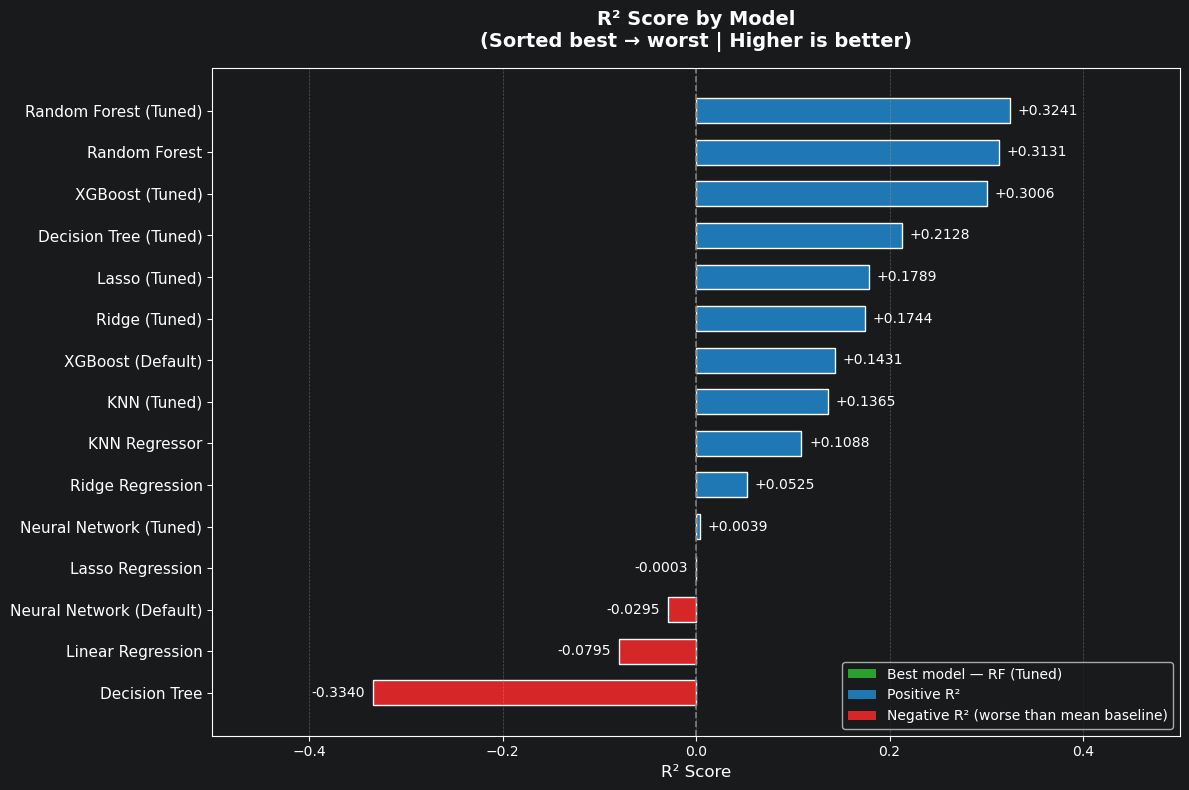

In [57]:

sorted_items = sorted(results.items(), key=lambda x: x[1]['R²'], reverse=True)
models = [i[0] for i in sorted_items]
rmse   = [i[1]['RMSE'] for i in sorted_items]
mae    = [i[1]['MAE']  for i in sorted_items]
r2     = [i[1]['R²']   for i in sorted_items]

colors_r2  = ['#2ca02c' if m == 'RF (Tuned) ★' else ('#d62728' if v < 0 else '#1f77b4')
              for m, v in zip(models, r2)]
colors_err = ['#2ca02c' if m == 'RF (Tuned) ★' else '#1f77b4' for m in models]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(models, r2, color=colors_r2, edgecolor='white', height=0.6)
ax.axvline(0, color='gray', linestyle='--', linewidth=1.2)

for i, v in enumerate(r2):
    ax.text(v + (0.008 if v >= 0 else -0.008), i, f'{v:+.4f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=10)
ax.set_title('R² Score by Model\n(Sorted best → worst | Higher is better)',  fontsize=14, fontweight='bold', pad=15)

ax.set_xlabel('R² Score', fontsize=12)
ax.set_xlim(-0.50, 0.50)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)

legend_elements = [
    Patch(facecolor='#2ca02c', label='Best model — RF (Tuned)'),
    Patch(facecolor='#1f77b4', label='Positive R²'),
    Patch(facecolor='#d62728', label='Negative R² (worse than mean baseline)'),
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('../plots/r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

***Interpretation:***

- **Random Forest (Tuned)** achieves the highest R<sup>2</sup> of **0.3241**, meaning it explains about `32.41%` of the variation in student GPA. The strongest result among all models.
- **XGBoost (Tuned)** follows closely at `0.3006`, confirming that ensemble tree methods capture GPA patterns better than linear or single tree models.
- The **untuned Decision Tree** **R<sup>2</sup> = -0.334** and **untuned Linear Regression** **R<sup>2</sup>  = -0.080** both fall below the mean.
- All **tuned models** except Neural Network improved significantly over their defaults, confirming that hyperparameter tuning was essential for all models.
- The **Neural Network**, even after tuning, barely reached **R<sup>2</sup> = 0.004**, suggesting that MLP models are not well suited to this tabular dataset.

### 12.2 RMSE (Root Mean Squared Error)

`RMSE` measures the average of prediction errors, with **larger errors penalized more heavily** because the differences are squared before averaging. Lower `RMSE` means the model makes fewer large mistakes.


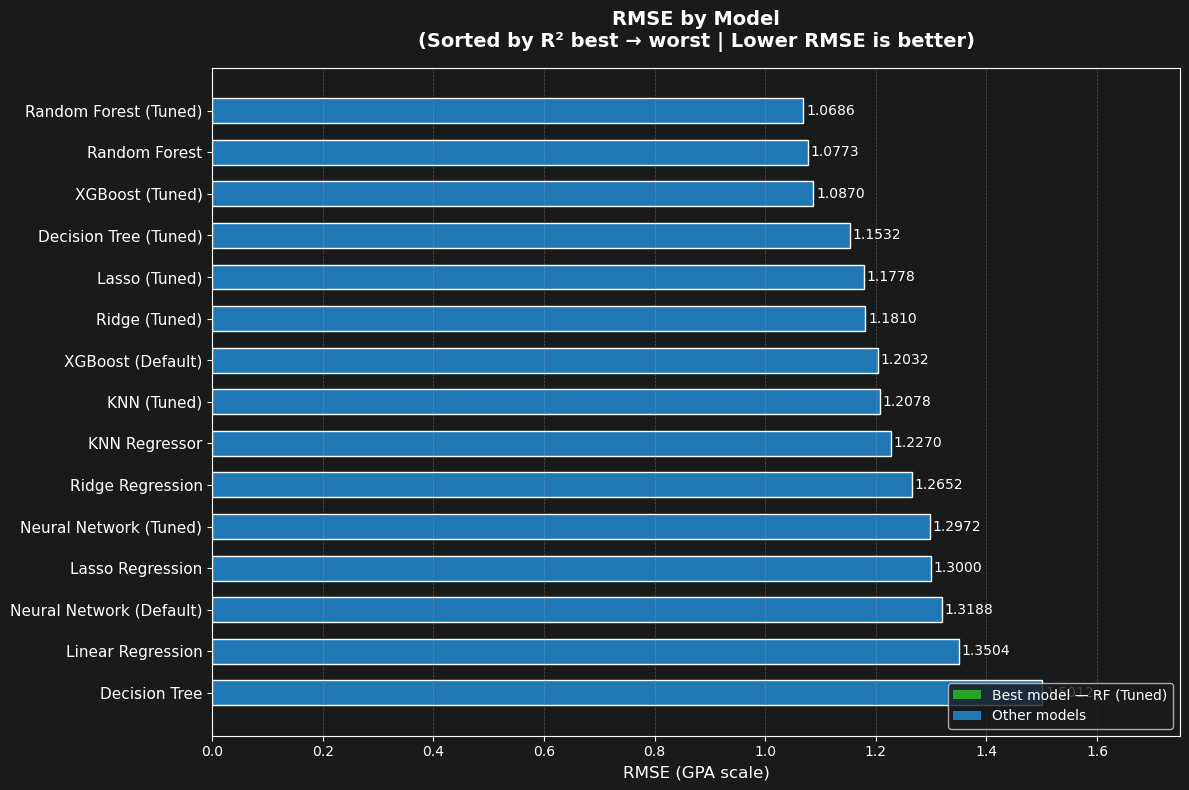

In [55]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(models, rmse, color=colors_err, edgecolor='white', height=0.6)

for i, v in enumerate(rmse):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', ha='left', fontsize=10)
ax.set_title('RMSE by Model\n(Sorted by R² best → worst | Lower RMSE is better)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('RMSE (GPA scale)', fontsize=12)
ax.set_xlim(0, 1.75)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)

legend_elements = [
    Patch(facecolor='#2ca02c', label='Best model — RF (Tuned)'),
    Patch(facecolor='#1f77b4', label='Other models'),
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('../plots/rmse_comparison.png', dpi=150, bbox_inches='tight')

plt.show()

***Interpretation:***

- **Random Forest (Tuned)** achieves the lowest `RMSE` of `1.0686`, meaning it makes the smallest errors when predicting GPA.
- **XGB (Tuned)** (RMSE = 1.087) and **Random Forest** (RMSE = 1.077) are very close, confirming that ensemble tree methods dominate on this metric.
- The **untuned Decision Tree** has the worst `RMSE` of `1.5012`, over `0.43` points worse than the tuned Random Forest, showing it was overfitting on training data.
- `RMSE` differences between the top 5 models are less than `0.05`, meaning all five are reasonable choices.

### 12.3 MAE (Mean Absolute Error)

MAE measures the average absolute difference between predicted and actual GPA values. Unlike RMSE, it treats all errors equally, so it gives a more direct sense of the typical prediction error in real-world terms.


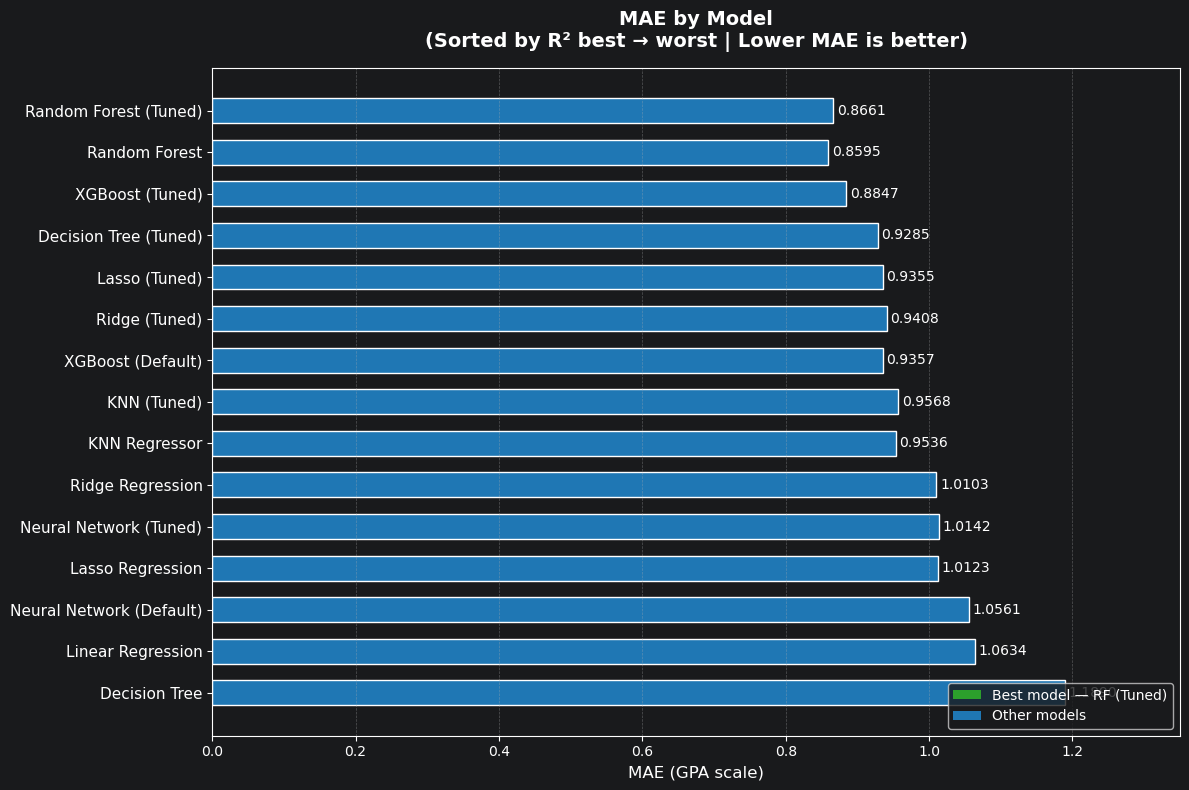

In [56]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(models, mae, color=colors_err, edgecolor='white', height=0.6)

for i, v in enumerate(mae):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', ha='left', fontsize=10)

ax.set_title('MAE by Model\n(Sorted by R² best → worst | Lower MAE is better)', fontsize=14, fontweight='bold', pad=15)

ax.set_xlabel('MAE (GPA scale)', fontsize=12)
ax.set_xlim(0, 1.35)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)

legend_elements = [
    Patch(facecolor='#2ca02c', label='Best model — RF (Tuned)'),
    Patch(facecolor='#1f77b4', label='Other models'),
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()

plt.savefig('../plots/mae_comparison.png', dpi=150, bbox_inches='tight')

plt.show()

***Interpretation:***

- **Random Forest** `MAE = 0.8595` has the lowest MAE among all models, followed closely by the tuned Random Forest `MAE = 0.8661` and tunedXGB `MAE = 0.8847`.
- The untuned Decision Tree showed the worst `MAE` with `1.189`, confirming its poor generalization on unseen data.
- The **Neural Network (Tuned)** `MAE = 1.014` performs only slightly better than the default version, confirming that MLP regression did not suit this dataset.

## 12.0 Final Model Selection

Across all three metrics, **Random Forest (Tuned)** is the best regression model
for predicting student GPA:

| Metric | RF (Tuned) Value | What it means                                           |
|--------|-----------------|---------------------------------------------------------|
| R²     | 0.3241          | Explains 32.4% of GPA variance                          |
| RMSE   | 1.0686          | Smallest rror magnitude                                 |
| MAE    | 0.8661          | Typical prediction off by aproximatelly 0.87 GPA points |


Ensemble tree models like Random Forest and XGBoost performed better than linear models and neural networks on this dataset, suggesting that student GPA is influenced by nonlinear feature that linear models cannot fully capture.